# 01_qc_review.ipynb

## 1. Setup and load merged table

## 2. Basic run completeness
- number of rows by TEL
- number of rows by TEL + HFILTER
- number with R measurements
- number with CS-ZP Hα measurements
- number with CS-gr Hα measurements

## 3. Missing Hα diagnostics
- fraction missing by TEL
- fraction missing by HFILTER
- missing vs FILTER_RATIO
- missing vs FILTER_CORRECTION
- missing vs H_SKYNOISE / CSGR_SKYSTD_PHYS
- missing vs H_FWHM / R_FWHM

## 4. INT-specific review
- INT rows with missing CS-ZP but valid R
- INT rows with missing CS-gr but valid R
- compare Halpha vs Ha6657
- date/pointing breakdown

## 5. Spatial diagnostics
- x_parent/y_parent maps colored by:
  - has H_R24_FLUX_CGS
  - has CSGR_H_R24_FLUX_CGS
  - FILTER_RATIO
  - H_SKYNOISE

## 6. Measurement distributions by telescope
- R24_FLUX_CGS
- H_R24_FLUX_CGS
- CSGR_H_R24_FLUX_CGS
- H50_ARCSEC
- CSGR_H50_ARCSEC

## 7. Outlier and failure tables
- write CSVs of problematic rows

In [34]:
from astropy.table import Table
from matplotlib import pyplot as plt
import numpy as np
from pathlib import Path

mycolors = plt.rcParams['axes.prop_cycle'].by_key()['color']

Text(0, 0.5, 'Number of Galaxies')

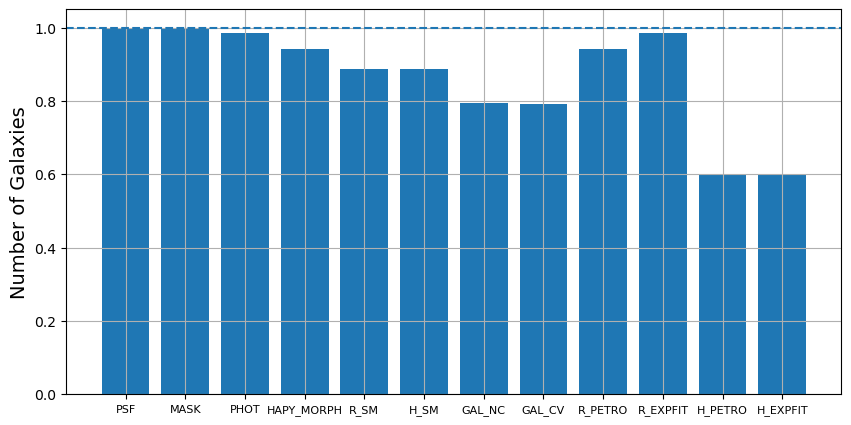

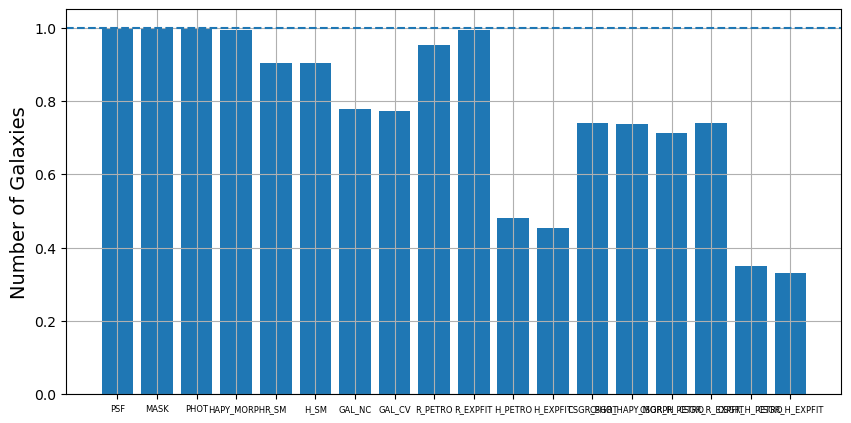

In [13]:
infile = '/Users/rfinn/research/Virgo/hatools_test/hapy-output-20260417/merged_results_virgo_20260421.fits'
tab = Table.read(infile)
infile = '/Users/rfinn/research/Virgo/hatools_test/hapy-output-20260417/merged_results_virgo_20260421.fits'
# hybrid data

okcol = [c for c in tab.colnames if 'OK' in c]
sums = []
labels = []
for ok in okcol:
    if "PROFILE" in ok:
        continue
    if "LOGFIT" in ok:
        continue
    sums.append(np.sum(tab[ok])/len(tab[ok]))
    labels.append(ok.replace('_OK',''))
plt.figure(figsize=(10,5))
plt.bar(labels,np.array(sums))
t = plt.xticks(fontsize=8)
plt.grid()

plt.axhline(y=1,ls='--')
plt.ylabel("Number of Galaxies",fontsize=14)


hybridmergedtab = Path.home() / 'research/Virgo/hapypost/tables/merged_results_virgo_20260520_with_best_duplicate.fits'

tab = Table.read(hybridmergedtab)


okcol = [c for c in tab.colnames if 'OK' in c]
sums = []
labels = []
for ok in okcol:
    if "PROFILE" in ok:
        continue
    if "LOGFIT" in ok:
        continue
    sums.append(np.sum(tab[ok])/len(tab[ok]))
    labels.append(ok.replace('_OK',''))
plt.figure(figsize=(10,5))
plt.bar(labels,np.array(sums))
t = plt.xticks(fontsize=6)
plt.grid()

plt.axhline(y=1,ls='--')
plt.ylabel("Number of Galaxies",fontsize=14)

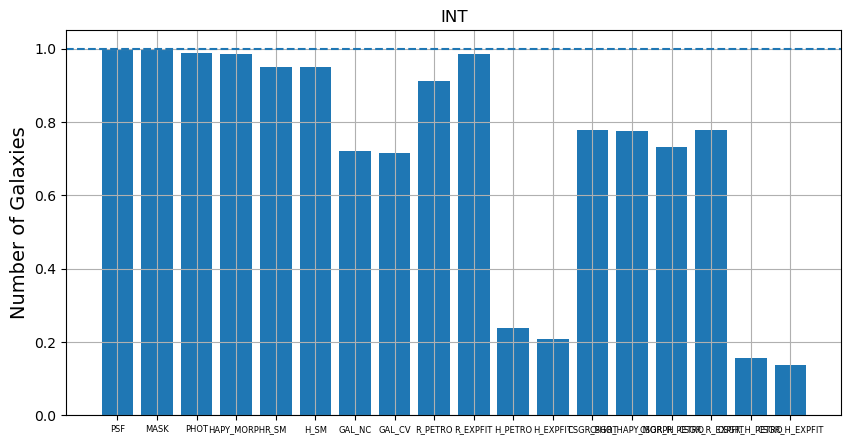

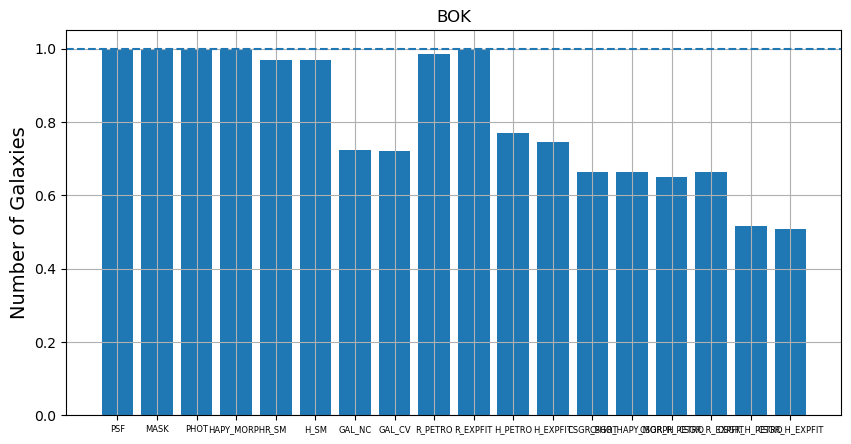

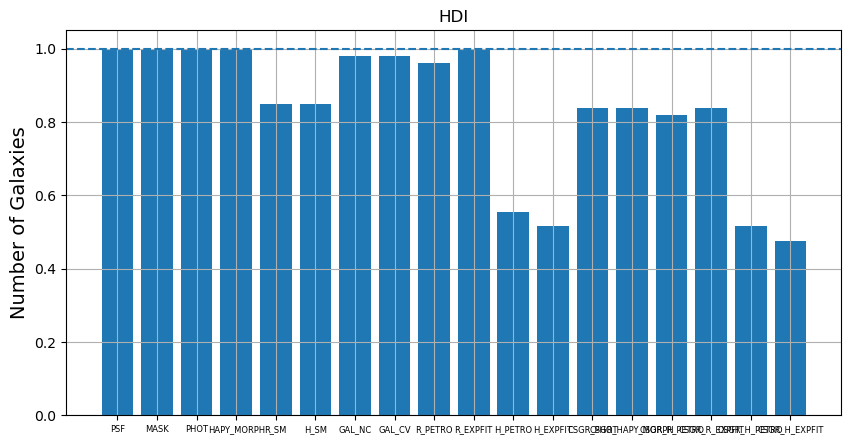

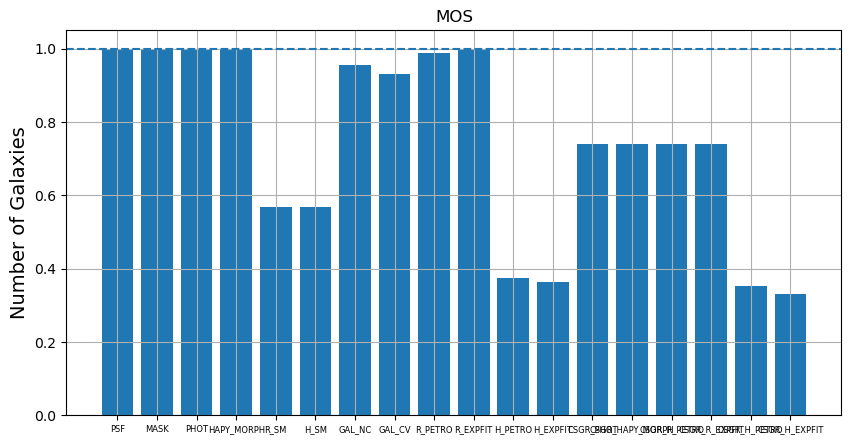

In [11]:
hybridmergedtab = Path.home() / 'research/Virgo/hapypost/tables/merged_results_virgo_20260520_with_best_duplicate.fits'

tab = Table.read(hybridmergedtab)

tels = ['INT','BOK','HDI','MOS']
for tel in tels:
    flag = tab['TELESCOPE'] == tel
    ttab = tab[flag]
    okcol = [c for c in ttab.colnames if 'OK' in c]# and (c.startswith("H"))]
    sums = []
    labels = []
    for ok in okcol:
        if "PROFILE" in ok:
            continue
        if "LOGFIT" in ok:
            continue
        sums.append(np.sum(ttab[ok])/len(ttab[ok]))
        labels.append(ok.replace('_OK',''))
    plt.figure(figsize=(10,5))
    plt.bar(labels,np.array(sums))
    t = plt.xticks(fontsize=6)
    plt.grid()
    plt.title(tel)
    
    plt.axhline(y=1,ls='--')
    plt.ylabel("Number of Galaxies",fontsize=14)

In [16]:
inttab = tab[tab["TELESCOPE"] == "INT"].copy()

fail = inttab["H_PROFILE_NGOOD"] == 0
ok = inttab["H_PROFILE_NGOOD"] > 0

cols = [
    "TAG", "HFILTER", "DATEOBS", "POINTING",
    "H_PROFILE_NGOOD", "CSGR_PROFILE_NGOOD",
    "FILTER_RATIO", "FILTER_CORRECTION",
    "H_SKYNOISE", "CSGR_SKYSTD_PHYS",
    "H_R24_FLUX_CGS", "CSGR_H_R24_FLUX_CGS",
    "H_HAPY_GINI", "CSGR_HAPY_GINI",
]

inttab[fail][[c for c in cols if c in inttab.colnames]]

TAG,HFILTER,DATEOBS,POINTING,H_PROFILE_NGOOD,FILTER_RATIO,FILTER_CORRECTION,CSGR_SKYSTD_PHYS,H_R24_FLUX_CGS,CSGR_H_R24_FLUX_CGS,H_HAPY_GINI,CSGR_HAPY_GINI
bytes512,bytes21,bytes8,bytes10,int64,float64,float64,float64,float64,float64,float64,float64
VFID0473-WISEAJ170712.75+605514.5-INT,Ha6657,20190603,p010,0,3.20869,1.3585666062557926,--,--,--,0.8880468163903186,--
VFID0481-NGC6307-INT-20190603-p010,Ha6657,20190603,p010,0,3.20869,1.4426387051188785,--,--,--,0.9705508464642305,--
VFID0569-NGC5989-INT-20190530-p002,Ha6657,20190530,p002,0,3.1692595,1.9944012746345237,5.350277747141943e-17,--,--,0.7700140089260026,0.8603668078063604
VFID0935-WISEAJ114820.15+562045.4-INT-20220502-VFID0957,Halpha,20220502,VFID0957,0,3.030015,1.02778386649198,3.9422365974868077e-17,--,--,0.9613347938791835,0.9612210615568962
VFID0958-SDSSJ114929.60+560154.1-INT-20220502-VFID0957,Halpha,20220502,VFID0957,0,3.030015,1.0122716998648196,3.704513478171339e-17,--,--,0.9342305415870131,0.9355109313245505
VFID0970-WISEAJ114634.08+554917.4-INT-20220502-VFID0957,Halpha,20220502,VFID0957,0,3.030015,1.034608309013668,4.934615362469686e-17,--,--,0.9198656287323668,0.9170506797839498
VFID0992-WISEAJ115702.24+553617.3-INT,Halpha,20220502,VFID1010,0,3.0934703,2.2749754644713214,--,--,--,0.9193794938387743,--
VFID0998-SDSSJ115703.08+553512.3-INT-20220502-VFID1010,Halpha,20220502,VFID1010,0,3.0934703,1.0039759312732537,3.685064041309779e-17,--,--,0.9893562106868475,0.9853030726365042
VFID1014-WISEAJ115701.80+552510.7-INT-20220502-VFID1010,Halpha,20220502,VFID1010,0,3.0934703,1.0531319972485977,3.754938032637376e-17,--,--,0.9719966558219197,0.9714648283006497


# Halpha Sky noise as function of telescope

Text(0.5, 0, 'H_SKYSTD_PHYS')

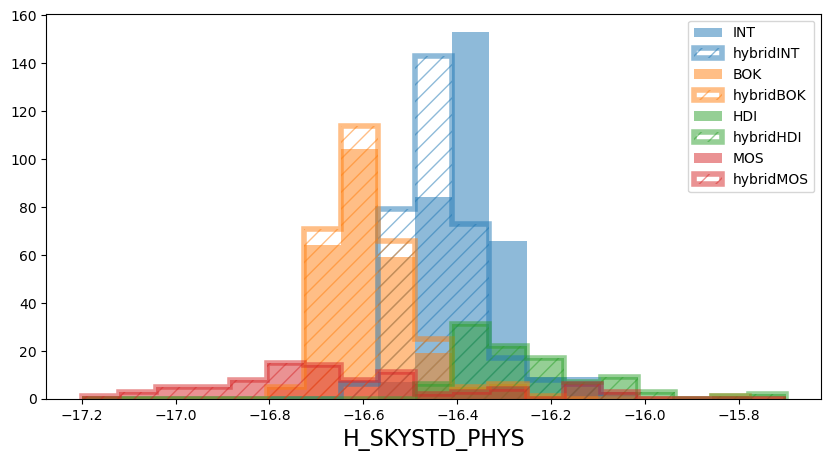

In [35]:
hybridmergedtab = Path.home() / 'research/Virgo/hapypost/tables/merged_results_virgo_20260520_with_best_duplicate.fits'
htab = Table.read(hybridmergedtab)

mergedtab = Path.home() / 'research/Virgo/hapypost/tables/merged_results_virgo_20260514_with_best_duplicate.fits'
tab = Table.read(mergedtab)

tels = ['INT','BOK','HDI','MOS']
xcol = "H_SKYSTD_PHYS"

x = tab[xcol]
hx = htab[xcol]
mybins = np.linspace(-17.2, -15.7, 20)
plt.figure(figsize=(10,5))
for i,tel in enumerate(tels):
    flag = tab['TELESCOPE'] == tel
    hflag = htab['TELESCOPE'] == tel
    plt.hist(np.log10(x[flag]),label=tel, alpha=.5, bins=mybins,color=mycolors[i])
    plt.hist(np.log10(hx[hflag]),label="hybrid"+tel, alpha=.5, bins=mybins,hatch='//',histtype='step',lw=4,color=mycolors[i])
    
plt.legend()

plt.xlabel(xcol,fontsize=16)

# so the hybrid INT Halpha sky noise is significantly lower, which is odd

# is the noise calibrated from the

Text(0.5, 0, 'H_SKYSTD_ADU')

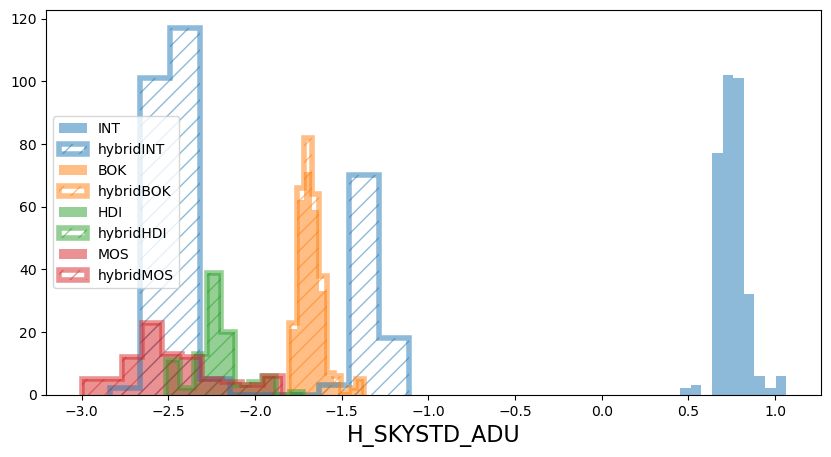

In [48]:
hybridmergedtab = Path.home() / 'research/Virgo/hapypost/tables/merged_results_virgo_20260520_with_best_duplicate.fits'
htab = Table.read(hybridmergedtab)

mergedtab = Path.home() / 'research/Virgo/hapypost/tables/merged_results_virgo_20260514_with_best_duplicate.fits'
tab = Table.read(mergedtab)

tels = ['INT','BOK','HDI','MOS']
xcol = "H_SKYSTD_ADU"

x = tab[xcol]
hx = htab[xcol]
#mybins = np.linspace(-17.2, -15.7, 20)
plt.figure(figsize=(10,5))
for i,tel in enumerate(tels):
    flag = tab['TELESCOPE'] == tel
    hflag = htab['TELESCOPE'] == tel
    if tel == "INT":
        hflag = hflag & (htab["HFILTER"] == "Halpha")
    plt.hist(np.log10(x[flag]),label=tel, alpha=.5, color=mycolors[i])
    plt.hist(np.log10(hx[hflag]),label="hybrid"+tel, alpha=.5, hatch='//',histtype='step',lw=4,color=mycolors[i])
    
plt.legend()

plt.xlabel(xcol,fontsize=16)

# so the hybrid INT Halpha sky noise is significantly lower, which is odd

# is the noise calibrated from the

In [62]:
for cn in tab.colnames: 
    if "FILT" in cn:
        print(cn)

HFILTER
RFILTER_FILENAME
RFILTER_CENTER
RFILTER_WIDTH
HFILTER_FILENAME
HFILTER_CENTER
HFILTER_WIDTH
FILTER_CORRECTION
FILTER_RATIO


In [44]:
set(htab["HFILTER"])

{'Ha+4nm',
 'Ha4nm',
 'Ha6657',
 'Halpha',
 'ha4',
 'ha4 H-',
 'ha4 H-alpha+4nm k1010'}

In [68]:
# INT sky noise in the hybrid dataset is bimodal - WTF?

higher_skystd = (htab["TELESCOPE"] == "INT") & (np.log10(htab["H_SKYSTD_ADU"]) > -1.5)

lower_skystd = (htab["TELESCOPE"] == "INT") & (np.log10(htab["H_SKYSTD_ADU"]) < -2.5)

In [66]:
for s in set(htab["PARENT_RIMAGE"][higher_skystd]):
    print(s) 

VF-181.749+43.081-INT-20220504-VFID1855-r.fits
VF-181.400+47.450-INT-20220502-VFID1534-r.fits
VF-224.580+06.750-INT-20220504-VFID5625-r.fits
VF-183.780+43.410-INT-20220503-VFID1819-r.fits
VF-233.701+16.331-INT-20220504-VFID4086-r.fits
VF-217.932+03.180-INT-20190210-p140-r.fits
VF-218.110+00.230-INT-20220503-VFID6620-r.fits
VF-220.750+04.720-INT-20220502-VFID5922-r.fits
VF-184.950+29.460-INT-20220505-VFID2935-r.fits
VF-182.270+43.664-INT-20220501-VFID1806-r.fits
VF-211.560+06.016-INT-20220505-VFID5726-r.fits
VF-215.900+01.700-INT-20220502-VFID6397-r.fits
VF-185.470+04.609-INT-20220505-VFID5966-r.fits
VF-177.200+56.055-INT-20220502-VFID0957-r.fits
VF-182.480+39.350-INT-20220503-VFID2171-r.fits
VF-188.900+27.940-INT-20220504-VFID3098-r.fits
VF-206.121+41.699-INT-20190211-p110-r.fits
VF-179.400+53.345-INT-20220501-VFID1168-r.fits
VF-179.740+50.875-INT-20220503-VFID1277-r.fits
VF-181.430+49.550-INT-20220503-VFID1376-r.fits
VF-234.076+16.541-INT-20220502-VFID4037-r.fits
VF-179.220+55.360-INT

In [69]:
for s in set(htab["PARENT_RIMAGE"][lower_skystd]):
    print(s) 

VF-158.816+26.127-INT-20190212-p060-r.fits
VF-141.327+34.480-INT-20190208-p031-r.fits
VF-208.591+41.310-INT-20190211-p121-r.fits
VF-177.174+26.955-INT-20190208-p091-r.fits
VF-210.394+36.758-INT-20190211-p128-r.fits
VF-151.381+28.899-INT-20190212-p047-r.fits
VF-161.262+34.959-INT-20190211-p062-r.fits
VF-138.973+34.482-INT-20190207-p023-r.fits
VF-130.869+49.783-INT-20190206-p013-r.fits
VF-147.645+33.546-INT-20190210-p041-r.fits
VF-197.921+24.094-INT-20190212-p102-r.fits
VF-145.608+31.863-INT-20190206-p035-r.fits
VF-155.130+25.361-INT-20190212-p052-r.fits
VF-140.168+40.115-INT-20190206-p027-r.fits
VF-170.022+26.960-INT-20190211-p072-r.fits
VF-139.164+25.421-INT-20190209-p024-r.fits
VF-157.087+29.490-INT-20190212-p056-r.fits
VF-203.859+35.580-INT-20190209-p106-r.fits
VF-205.200+33.792-INT-20190208-p109-r.fits
VF-208.804+05.187-INT-20190206-p120-r.fits
VF-182.337+25.025-INT-20190212-p095-r.fits
VF-135.052+25.596-INT-20190207-p021-r.fits
VF-134.940+31.950-INT-20190206-p020-r.fits
VF-147.617+

In [71]:
for cn in htab.colnames:
    if "DATE" in cn:
        print(cn)

RUN_DATE
DATEOBS


In [74]:
htab["DATEOBS"][0]

'20210414'

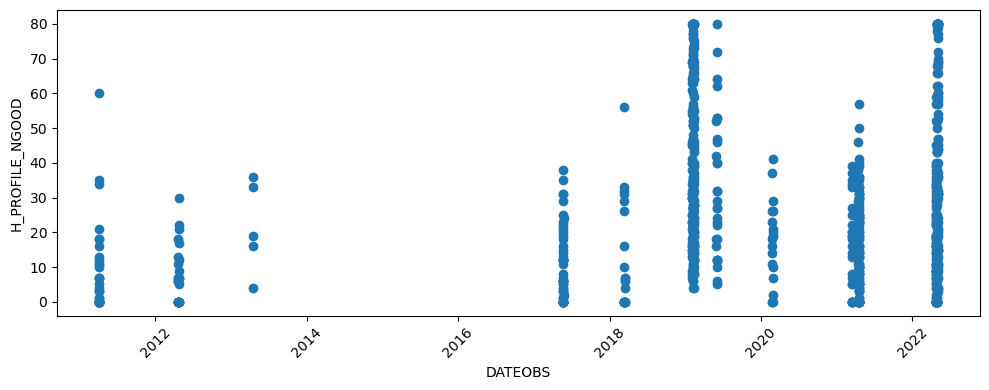

In [82]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def clean_dateobs(x):
    if isinstance(x, bytes):
        x = x.decode()
    return str(x).strip().replace("b'", "").replace("'", "")

date_str = [clean_dateobs(x) for x in tab["DATEOBS"]]
dates = pd.to_datetime(date_str, format="%Y%m%d", errors="coerce")



plt.figure(figsize=(10,4))
plt.plot(dates, tab["H_PROFILE_NGOOD"], "o")
plt.xlabel("DATEOBS")
plt.ylabel("H_PROFILE_NGOOD")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

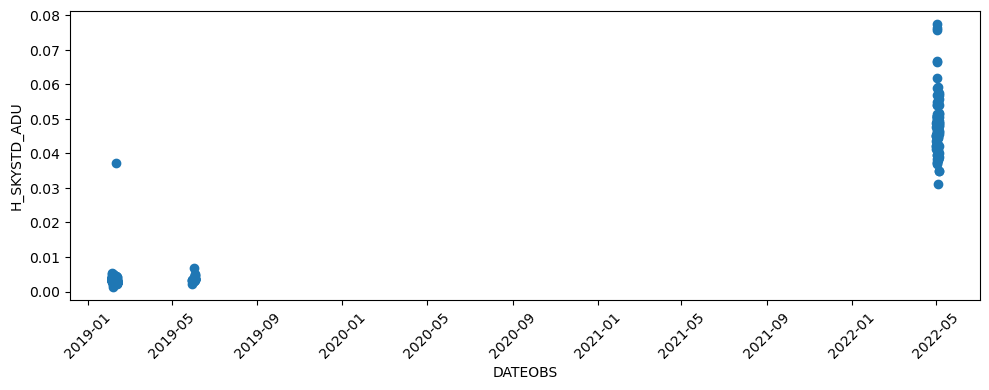

In [86]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def clean_dateobs(x):
    if isinstance(x, bytes):
        x = x.decode()
    return str(x).strip().replace("b'", "").replace("'", "")

int_tab = htab[htab["TELESCOPE"] == "INT"]
date_str = [clean_dateobs(x) for x in int_tab["DATEOBS"]]
dates = pd.to_datetime(date_str, format="%Y%m%d", errors="coerce")



plt.figure(figsize=(10,4))
plt.plot(dates, int_tab["H_SKYSTD_ADU"], "o")
plt.xlabel("DATEOBS")
plt.ylabel("H_SKYSTD_ADU")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# GAIN is 2.8 in 2019 and 1800 in 2022!  that is quite a difference!
# is one normalized by expt and the other not?  what is happening???

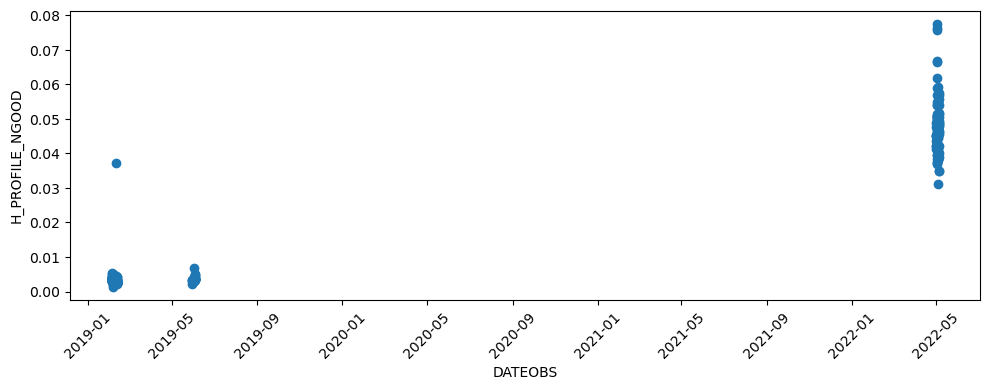

In [87]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def clean_dateobs(x):
    if isinstance(x, bytes):
        x = x.decode()
    return str(x).strip().replace("b'", "").replace("'", "")

int_tab = htab[htab["TELESCOPE"] == "INT"]
date_str = [clean_dateobs(x) for x in int_tab["DATEOBS"]]
dates = pd.to_datetime(date_str, format="%Y%m%d", errors="coerce")



plt.figure(figsize=(10,4))
plt.plot(dates, int_tab["H_SKYSTD_ADU"], "o")
plt.xlabel("DATEOBS")
plt.ylabel("H_PROFILE_NGOOD")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# GAIN is 2.8 in 2019 and 1800 in 2022!  that is quite a difference!
# is one normalized by expt and the other not?  what is happening???

# this seems to be linked directly to how well the profiles are fit.

Text(0.5, 0, 'CSGR_CONTSCL')

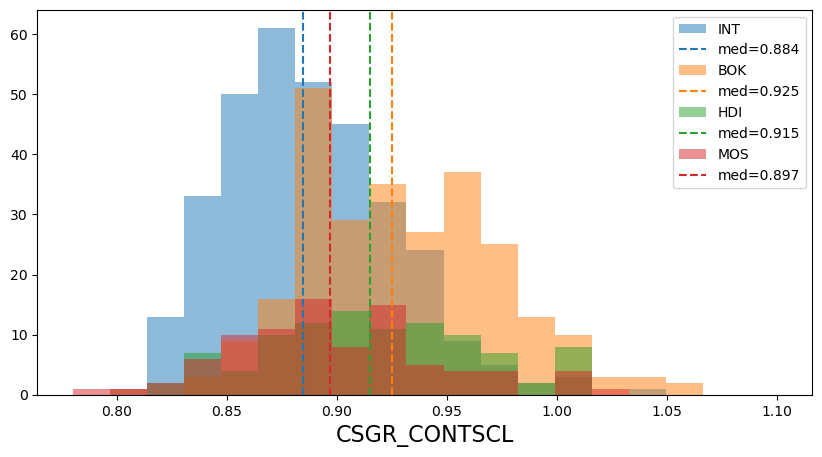

In [91]:
#hybridmergedtab = Path.home() / 'research/Virgo/hapypost/tables/merged_results_virgo_20260520_with_best_duplicate.fits'
#htab = Table.read(hybridmergedtab)

mergedtab = Path.home() / 'research/Virgo/hapypost/tables/merged_results_virgo_20260514_with_best_duplicate.fits'
tab = Table.read(mergedtab)

tels = ['INT','BOK','HDI','MOS']
xcol = "CSGR_CONTSCL"

x = tab[xcol]
#hx = htab[xcol]
mybins = np.linspace(.78, 1.1, 20)
plt.figure(figsize=(10,5))
for i,tel in enumerate(tels):
    flag = tab['TELESCOPE'] == tel
    hflag = htab['TELESCOPE'] == tel
    plt.hist((x[flag]),label=tel, alpha=.5, bins=mybins,color=mycolors[i])
    med = np.median(x[flag])
    plt.axvline(med,c=mycolors[i],ls='--',label=f"med={med:.3f}")
    #plt.hist(np.log10(hx[hflag]),label="hybrid"+tel, alpha=.5, bins=mybins,hatch='//',histtype='step',lw=4,color=mycolors[i])
    
plt.legend()

plt.xlabel(xcol,fontsize=16)

# so the hybrid INT Halpha sky noise is significantly lower, which is odd

# is the noise calibrated from the